In this notebook, we shall take a look at the Heat Equation with fixed diffusion rate and fixed boundary conditions :

$$ u_t = \alpha u_{xx} $$
$$ u(0,t) = u(1,t) = 0 $$

We shall be implementing a DeepONet architecture to learn the solution operator, $\mathcal{G}$ that maps the initial condition $u(x,0) = a(x)$ to the PDE solution $u(x,t)$. Thus,

$$ \mathcal{G}:a(x)\mapsto u(x,t) $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

# 1. Data Generation.

We need to train the DeepONet using large number of training examples. For this, we generate multiple initial conditin functions of the form :

$$ a(x) = \sum_{n=1}^N A_n \sin(n\pi x) $$

where we take $A_n\in \mathcal{U}(-1,1)$. Note that we intentionally refrained from including the cosine terms as they would have violated the boundary conditions.

For the initial condition above, the heat equation can exactly be solved giving the solution :

$$ u(x,t) = \sum_{n=1}^N A_n e^{-\alpha (n\pi)^2 t}\sin(n\pi x) $$

In [2]:
# constants and parameters
pi = torch.pi
alpha = 0.1

N_train = 1000                      # number of training functions
N_test = 200                        # number of testing functions
N_coeff = 10                        # number of fourier modes used to construct initial conditions
N_sensor = 50                       # number of sensor points
N_query = [60,80]                   # [no. of x-query locations, no. of t-query locations]
embed_dim = 64                      # dimension of the embedding latent space

### Dimensions.

The dimension of $x$ needs to be : $ \text{N-func} \times \text{N-sensory} $

The dimension of $u$ needs to be : $ \text{N-func} \times \text{N-query-x} \times \text{N-query-t} $

In [3]:
# input and output functions generator for given coefficients
def input_output_funcs(N_func, A_coeff, sensor_points, query_points, N_coeff, N_sensor, N_query):
    # N_query is assumed to be list of form [N_x_query, N_t_query]
    # query points are assumed to be a list contain torch.tensors : x_query_points and t_query_points (non-meshed versions)
    x_query_mesh, t_query_mesh = torch.meshgrid(query_points[0], query_points[1], indexing='ij')
    N_x_query, N_t_query = len(query_points[0]), len(query_points[1])
    a = torch.zeros((N_func,N_sensor))
    u = torch.zeros((N_func,N_query[0],N_query[1]))
    for n in range(N_coeff):
        a += torch.outer(A_coeff[:,n], torch.sin((n+1) * pi * sensor_points))
        u += torch.outer(A_coeff[:,n], (torch.sin((n+1) * pi * x_query_mesh) * torch.exp(-alpha * pi**2 * (n+1)**2 *t_query_mesh)).flatten()).reshape(N_func,N_x_query,N_t_query)
    return a,u

In [4]:
# testing the input_output function generator
A_coeff_test = torch.tensor([[1.0, 0.0], [0.0,1.0]])
N_coeff_test = len(A_coeff_test[0])
sensor_points_test = torch.linspace(0.0,1.0,N_sensor)
query_points_test = [torch.linspace(0.0,1.0,N_query[0]), torch.linspace(0.0,1.0,N_query[1])]
a_test, u_test = input_output_funcs(2, A_coeff_test, sensor_points_test, query_points_test, N_coeff_test, N_sensor, N_query)

Initial Conditions


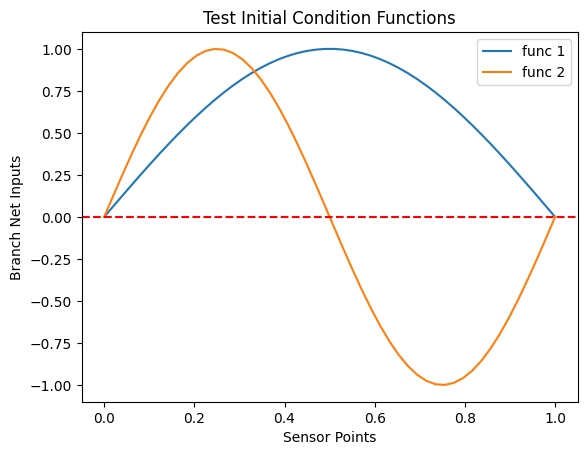

In [5]:
print("Initial Conditions")
plt.plot(sensor_points_test, a_test[0], label = 'func 1')
plt.plot(sensor_points_test, a_test[1], label = 'func 2')
plt.axhline(0, ls = '--', c = 'red')
plt.title("Test Initial Condition Functions")
plt.legend()
plt.xlabel("Sensor Points")
plt.ylabel("Branch Net Inputs")
plt.show()

Solutions


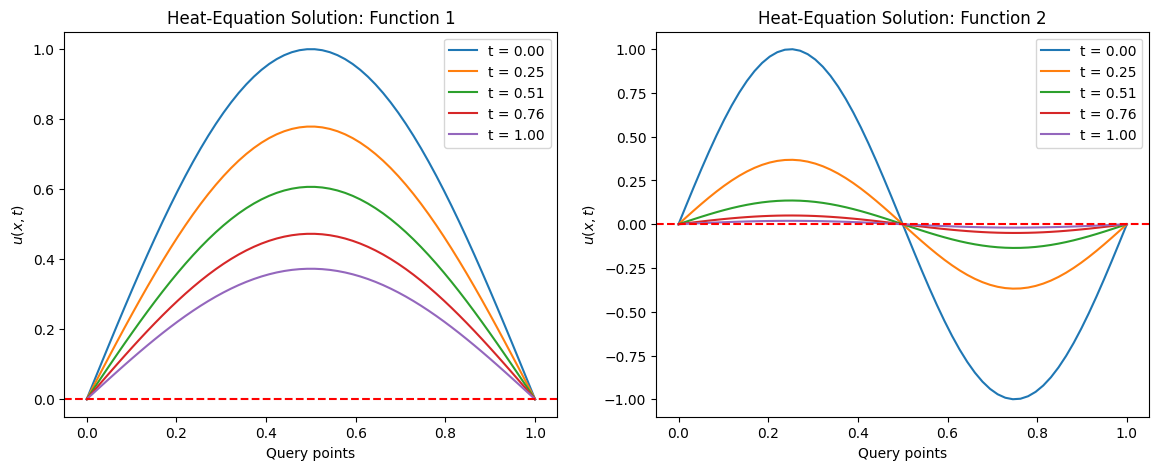

In [6]:
print("Solutions")
x_query_test = query_points_test[0]
t_query_test = query_points_test[1]

time_indices = [0,len(t_query_test) // 4,len(t_query_test) // 2,3 * len(t_query_test) // 4,len(t_query_test) - 1]

plt.figure(figsize=(14, 5))
for function_index in range(2):
    plt.subplot(1,2,function_index+1)
    for time_index in time_indices:
        plt.plot(x_query_test, u_test[function_index, :, time_index], label=f"t = {t_query_test[time_index].item():.2f}")

    plt.axhline(0, linestyle="--", color="red")
    plt.xlabel(r"Query points")
    plt.ylabel(r"$u(x,t)$")
    plt.title(f"Heat-Equation Solution: Function {function_index + 1}")
    plt.legend()
plt.show()

Thus, the input and output functions generator is working correctly.

In [7]:
# generating random input functions and corresponding output solutions
coeff_train = 2 * torch.rand((N_train, N_coeff)) - 1
coeff_test = 2 * torch.rand((N_test, N_coeff)) - 1
sensor_points = torch.linspace(0.0, 1.0, N_sensor)
query_points = [torch.linspace(0.0,1.0,N_query[0]), torch.linspace(0.0,1.0,N_query[1])]
x_train, u_train = input_output_funcs(N_train, coeff_train, sensor_points, query_points, N_coeff, N_sensor, N_query)
x_test, u_test = input_output_funcs(N_test, coeff_test, sensor_points, query_points, N_coeff, N_sensor, N_query)

# 2. DeepONet Architecture

In [8]:
class DeepONet(nn.Module):
    def __init__(self,N_sensor,embed_dim):
        super().__init__()

        self.BranchNet = nn.Sequential(
            nn.Linear(N_sensor, 64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,embed_dim)
        )

        self.TrunkNet = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,embed_dim)
        )

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, BranchInput, TrunkInput):
        b = self.BranchNet(BranchInput)
        t = self.TrunkNet(TrunkInput)
        return b @ t.T + self.bias

In [9]:
# defining the loss function
def Loss(model, branch_input, trunck_input, u_true):
    u_pred = model(branch_input, trunck_input)
    mse_loss = torch.mean((u_pred - u_true.reshape(-1,N_query[0]*N_query[1]))**2)
    return mse_loss, u_pred

In [10]:
# defining the DeepONet Class object and optimizers
model = DeepONet(N_sensor, embed_dim)
# Adam Optimizer
adam_optim = torch.optim.Adam(model.parameters(), lr = 0.001)
# LBFGS Optimizer
lbfgs_optim = torch.optim.LBFGS(model.parameters(), lr = 1.0, max_iter=60000, max_eval=60000, tolerance_grad=10**-10, tolerance_change=10**-14, line_search_fn="strong_wolfe")

In [11]:
x_query_mesh, t_query_mesh = torch.meshgrid(query_points[0], query_points[1],indexing = 'ij')
query_points_reshaped = torch.column_stack((x_query_mesh.flatten(),t_query_mesh.flatten()))
print(query_points_reshaped.shape)

torch.Size([4800, 2])


In [12]:
# training the model
# using Adam optimizer
N_epochs = 5000
adam_loss_arr = []
print(f"Training using using Adam optimizer started for {N_epochs} epochs ...")
for epoch in range(N_epochs):
    adam_optim.zero_grad()
    loss, _ = Loss(model, x_train, query_points_reshaped, u_train)
    adam_loss_arr.append(loss.item())
    loss.backward()
    adam_optim.step()
    if epoch % int(N_epochs/10) == 0:
        print(f"Epoch : {epoch} | loss = {loss.item():.6e}")
print("Training using using Adam optimizer finished.\n")

# using lbfgs optimizer
lbfgs_loss_arr = []
print("Training using using LBFGS optimizer started ...")
def closure():
    lbfgs_optim.zero_grad()
    loss, _ = Loss(model, x_train, query_points_reshaped, u_train)
    lbfgs_loss_arr.append(loss.item())
    loss.backward()
    return loss

lbfgs_optim.step(closure)
print("Training using using LBFGS optimizer finished.")
print(f"Final L-BFGS loss: {lbfgs_loss_arr[-1]:.6e}")

Training using using Adam optimizer started for 5000 epochs ...
Epoch : 0 | loss = 1.384688e-01
Epoch : 500 | loss = 3.280165e-02
Epoch : 1000 | loss = 2.658070e-02
Epoch : 1500 | loss = 2.258171e-02
Epoch : 2000 | loss = 3.053989e-02
Epoch : 2500 | loss = 1.881159e-02
Epoch : 3000 | loss = 1.867493e-02
Epoch : 3500 | loss = 2.232054e-02
Epoch : 4000 | loss = 1.729996e-02
Epoch : 4500 | loss = 1.585778e-02
Training using using Adam optimizer finished.

Training using using LBFGS optimizer started ...
Training using using LBFGS optimizer finished.
Final L-BFGS loss: 4.568335e-05


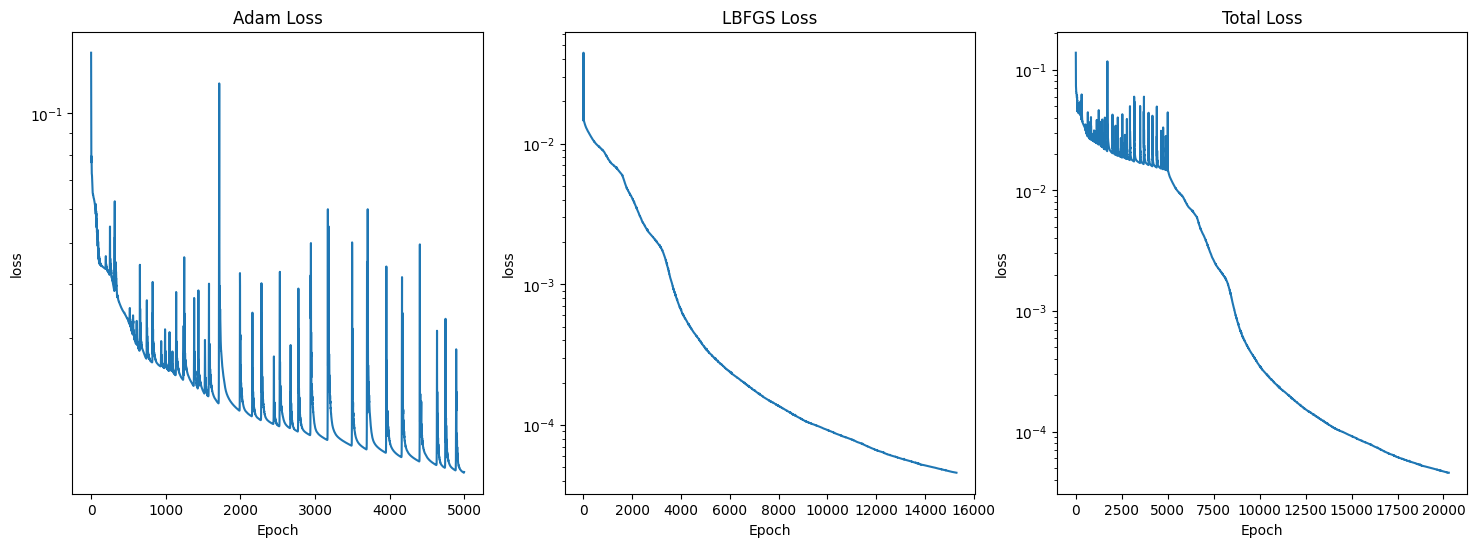

In [13]:
# visualing the loss
plt.figure(figsize = (18,6))

plt.subplot(1,3,1)
plt.semilogy(adam_loss_arr)
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,2)
plt.semilogy(lbfgs_loss_arr)
plt.title("LBFGS Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,3)
plt.semilogy(adam_loss_arr + lbfgs_loss_arr)
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()

# 3. Testing the Model.

In [14]:
# MSE
with torch.no_grad():
    u_test_pred = model(x_test, query_points_reshaped)
    u_train_pred = model(x_train, query_points_reshaped)

train_mse = torch.mean((u_train.reshape(-1, N_query[0] * N_query[1]) - u_train_pred)**2)
test_mse = torch.mean((u_test.reshape(-1, N_query[0] * N_query[1]) - u_test_pred)**2)
print(f"Test MSE: {test_mse.item():.6e}")
print(f"Train MSE: {train_mse.item():.6e}")

Test MSE: 4.772918e-05
Train MSE: 4.568335e-05


In [15]:
# Relative L-square error
relative_errors = (torch.linalg.vector_norm( u_test_pred - u_test.reshape(-1, N_query[0] * N_query[1]), dim=1 ) / torch.linalg.vector_norm( u_test.reshape(-1, N_query[0] * N_query[1]), dim=1 ))
mean_relative_error = relative_errors.mean()
print("Mean relative L2 error:",mean_relative_error.item())

Mean relative L2 error: 0.021256113424897194


In [16]:
# Reshape predicted test solutions
u_test_pred_grid = u_test_pred.reshape(N_test, N_query[0], N_query[1])

print("Exact solution shape:", u_test.shape)
print("Predicted solution shape:", u_test_pred_grid.shape)

Exact solution shape: torch.Size([200, 60, 80])
Predicted solution shape: torch.Size([200, 60, 80])


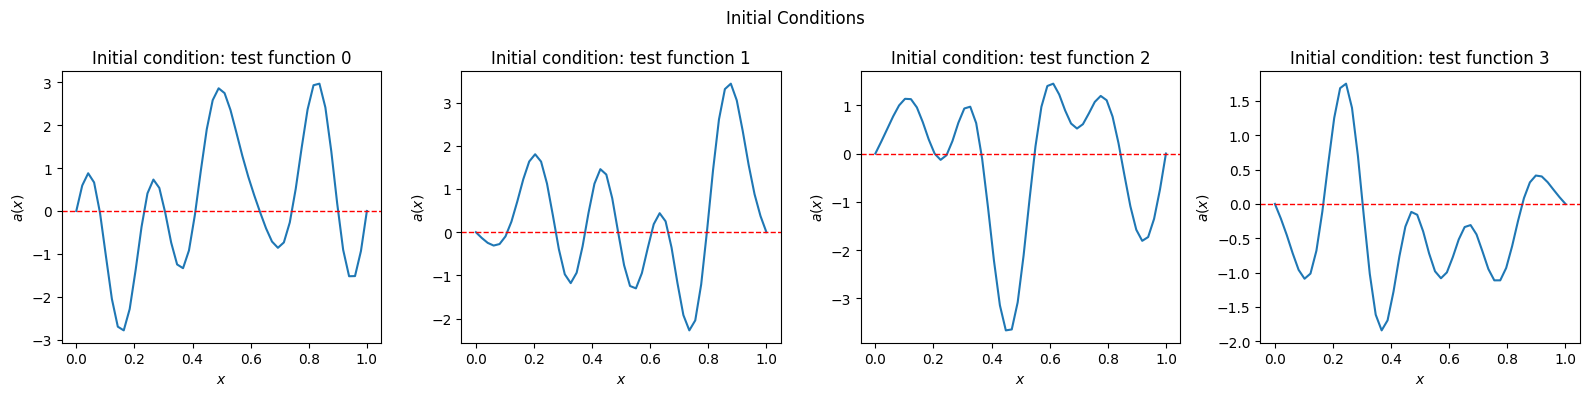

In [17]:
function_indices = [0, 1, 2, 3]

plt.figure(figsize=(16, 4))

for plot_index, function_index in enumerate(function_indices):
    plt.subplot(1, 4, plot_index + 1)

    plt.plot(
        sensor_points.detach().cpu().numpy(),
        x_test[function_index].detach().cpu().numpy()
    )

    plt.axhline(
        0.0,
        color="red",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$a(x)$")
    plt.title(f"Initial condition: test function {function_index}")

plt.suptitle("Initial Conditions")
plt.tight_layout()
plt.show()

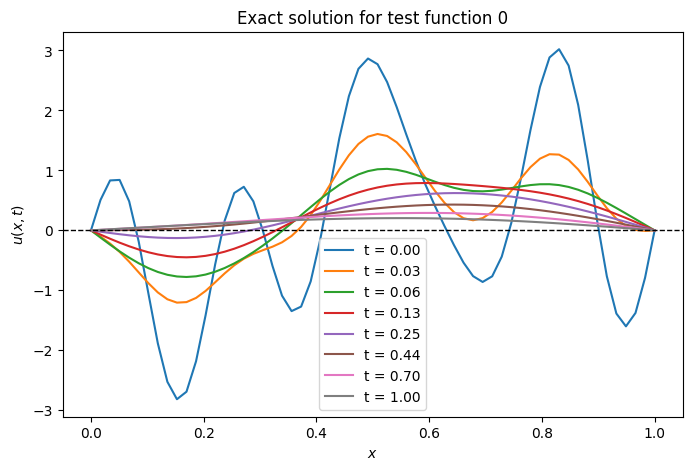

In [28]:
function_index = 0

time_indices = [0,2,5,10,20,35,55,79]

plt.figure(figsize=(8, 5))

for time_index in time_indices:
    plt.plot(query_points[0].detach().cpu().numpy(),u_test[function_index, :, time_index].detach().cpu().numpy(),label=f"t = {query_points[1][time_index].item():.2f}")

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,t)$")
plt.title(f"Exact solution for test function {function_index}")
plt.legend()
plt.show()

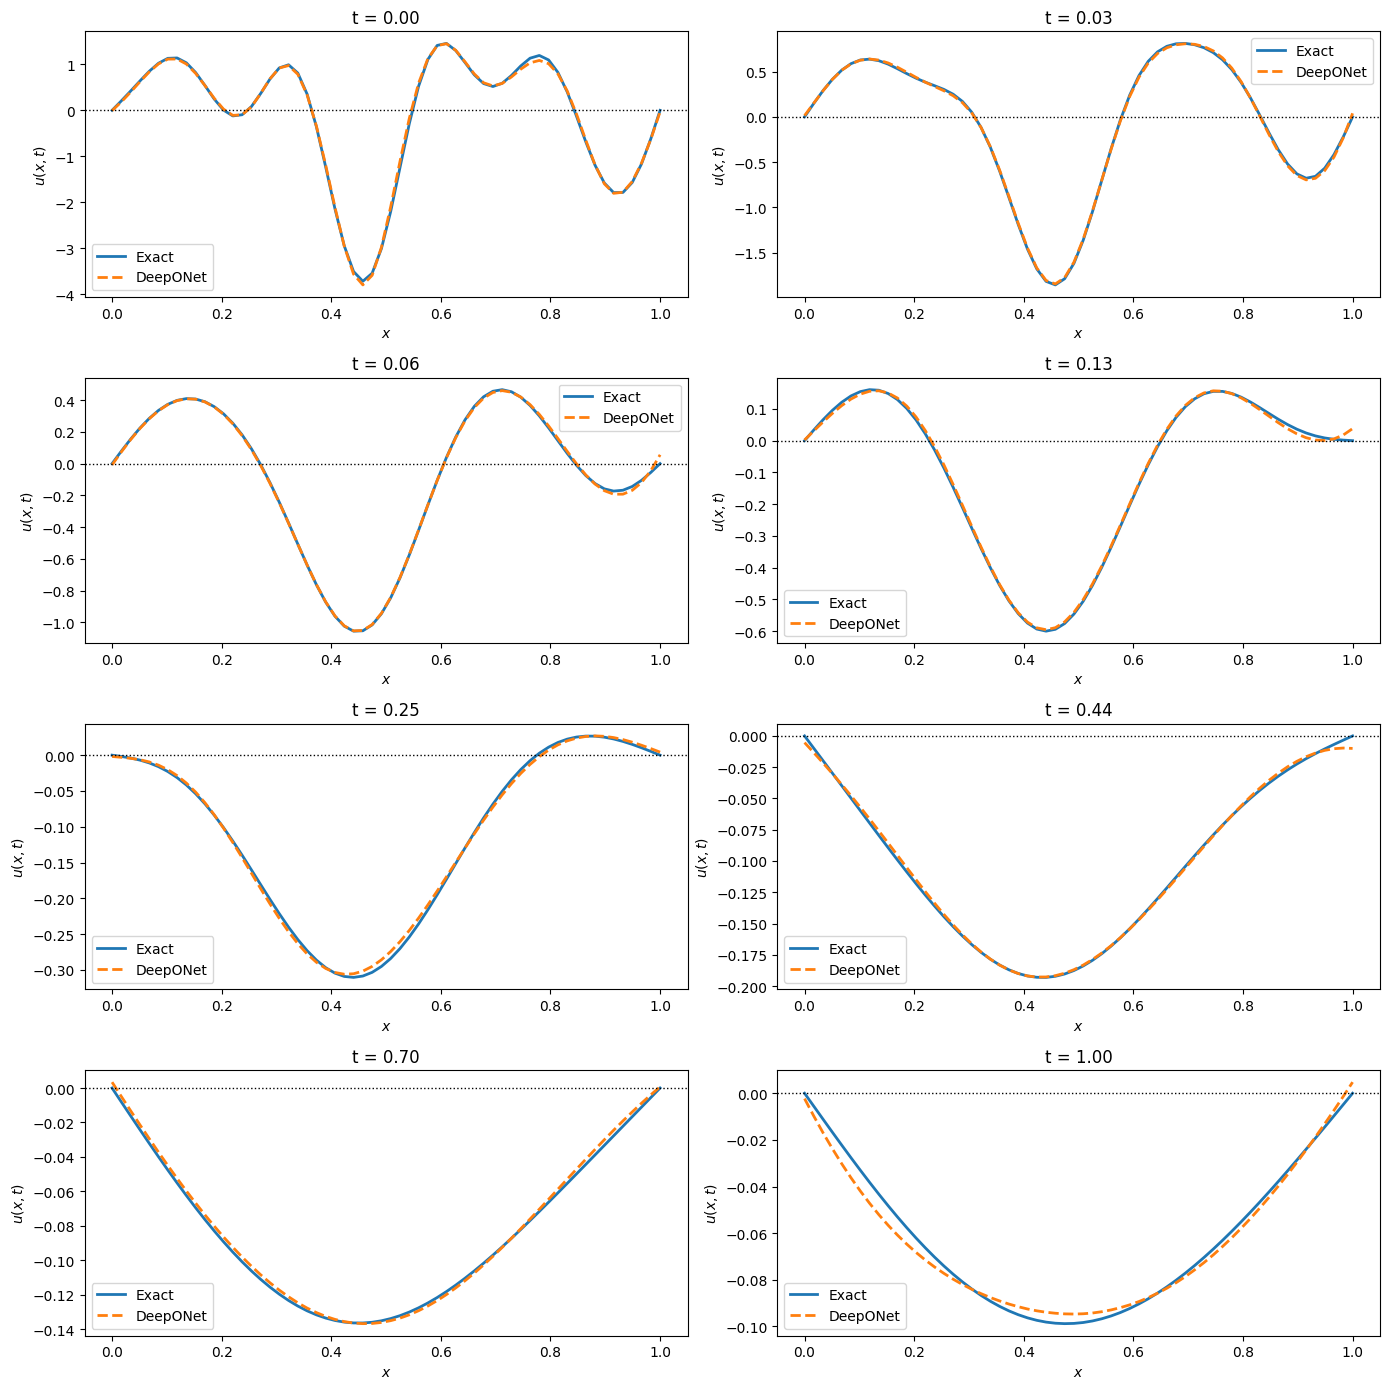

In [ ]:
function_index = 2

plt.figure(figsize=(14, 14))
for plot_index, time_index in enumerate(time_indices):
    plt.subplot(4, 2, plot_index + 1)

    # Exact solution
    plt.plot(
        query_points[0].detach().cpu().numpy(),
        u_test[function_index, :, time_index].detach().cpu().numpy(),
        label="Exact",
        linewidth=2
    )

    # DeepONet prediction
    plt.plot(
        query_points[0].detach().cpu().numpy(),
        u_test_pred_grid[
            function_index,
            :,
            time_index
        ].detach().cpu().numpy(),
        label="DeepONet",
        linestyle="--",
        linewidth=2
    )

    plt.axhline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$u(x,t)$")
    plt.title(
        f"t = {query_points[1][time_index].item():.2f}"
    )

    plt.legend()

plt.tight_layout()
plt.show()

### Remarks.

Thus, we successfully learnt out solution operator for the Heat Equation with a fixed diffusion constant.